In [152]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


READ DATASET

In [153]:
df = pd.read_csv("group_02_train.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   f1      100000 non-null  str    
 1   f2      100000 non-null  str    
 2   f3      100000 non-null  str    
 3   f4      55967 non-null   float64
 4   f5      55967 non-null   float64
 5   f6      100000 non-null  float64
 6   f7      100000 non-null  str    
 7   f8      99995 non-null   str    
 8   f9      100000 non-null  str    
 9   f10     99976 non-null   str    
 10  f11     99904 non-null   str    
 11  f12     98471 non-null   str    
 12  f13     74248 non-null   float64
 13  f14     97814 non-null   float64
 14  f15     98198 non-null   float64
 15  f16     97750 non-null   float64
 16  f17     97767 non-null   str    
 17  f18     92562 non-null   float64
 18  f19     71490 non-null   float64
 19  f20     100000 non-null  bool   
 20  f21     100000 non-null  bool   
 21  f22     100000 non-nul

In [154]:
df.head()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f26,f27,f28,f29,f30,f31,f32,f33,f34,y
0,Source2,2020-02-25 07:49:44,2020-02-25 08:34:09,NaN,NaN,0.620,Accident on entry ramp to I-75 Southbound from...,Cincinnati,OH,45225,...,False,False,False,False,False,Day,Day,Day,Day,2
1,Source1,2022-12-02 17:39:54,2022-12-02 19:01:07,32.301765,-95.307592,0.103,Incident on RICHMOND RD near W SOUTHWEST LOOP ...,Tyler,TX,75701-9405,...,False,False,False,False,False,Night,Day,Day,Day,2
2,Source2,2020-10-08 07:10:53,2020-10-08 07:55:42,NaN,NaN,0.000,Right hand shoulder blocked due to accident on...,Providence,RI,02909,...,False,False,False,False,False,Day,Day,Day,Day,2
3,Source1,2021-06-13 15:13:35.000000000,2021-06-13 16:05:00.000000000,38.615910,-76.877388,0.439,Stationary traffic on MD-5 from Renner Rd (Leo...,Waldorf,MD,20601,...,False,False,False,False,False,Day,Day,Day,Day,2
4,Source1,2018-12-04 07:55:37,2018-12-04 08:25:14,39.852800,-86.276120,0.271,At 56th St/Exit 19 - Accident.,Indianapolis,IN,46254,...,False,False,False,False,False,Day,Day,Day,Day,3


,Column,Non-Null Count,Data Type,Missing Values,Missing (%)
f4,f4,55967,float64,44033,44.03
f5,f5,55967,float64,44033,44.03
f19,f19,71490,float64,28510,28.51
f13,f13,74248,float64,25752,25.75
f18,f18,92562,float64,7438,7.44
f16,f16,97750,float64,2250,2.25
f17,f17,97767,str,2233,2.23
f14,f14,97814,float64,2186,2.19
f15,f15,98198,float64,1802,1.80
f12,f12,98471,str,1529,1.53


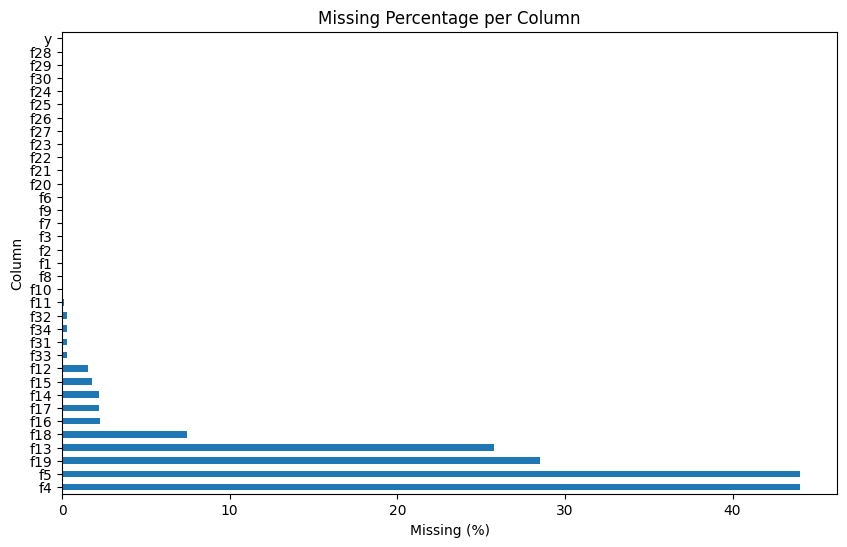

In [155]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Non-Null Count": df.notnull().sum(),
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().sum() / len(df)) * 100
})

summary = summary.sort_values(by="Missing (%)", ascending=False)

display(
    summary.style
    .background_gradient(subset=["Missing (%)"], cmap='Reds')
    .bar(subset=["Non-Null Count"], color='#5fba7d')
    .format({"Missing (%)": "{:.2f}"})
)

plt.figure(figsize=(10,6))
summary.set_index("Column")["Missing (%)"].plot(
    kind='barh',
    title='Missing Percentage per Column'
)
plt.xlabel("Missing (%)")
plt.show()

In [156]:
df = df.drop(columns=['f7']) 
df = df.drop(columns=['f2', 'f3'])  
df = df.drop(columns=['f4', 'f5'])
len(df.columns)

30

The column f7 was removed because it contains unstructured text data that requires complex preprocessing. Columns f2 and f3 were removed since they are datetime features stored as strings and were not directly usable in the model. Columns f4 and f5 were removed due to having a high percentage of missing values (around 44%), which could negatively affect model performance.


In [157]:
bool_cols = df.select_dtypes(include=['bool']).columns

df[bool_cols] = df[bool_cols].astype(int)

In [158]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Non-Null Count": df.notnull().sum(),
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().sum() / len(df)) * 100
})

summary = summary.sort_values(by="Missing (%)", ascending=False)

display(
    summary.style
    .background_gradient(subset=["Missing (%)"], cmap='Reds')
    .bar(subset=["Non-Null Count"], color='#5fba7d')
    .format({"Missing (%)": "{:.2f}"})
)

,Column,Non-Null Count,Data Type,Missing Values,Missing (%)
f19,f19,71490,float64,28510,28.51
f13,f13,74248,float64,25752,25.75
f18,f18,92562,float64,7438,7.44
f16,f16,97750,float64,2250,2.25
f17,f17,97767,str,2233,2.23
f14,f14,97814,float64,2186,2.19
f15,f15,98198,float64,1802,1.80
f12,f12,98471,str,1529,1.53
f33,f33,99715,str,285,0.29
f32,f32,99715,str,285,0.29


In [159]:
cat_summary = pd.DataFrame({
    "Column": df.select_dtypes(include=['object']).columns,
    "Unique Values": [df[col].nunique() for col in df.select_dtypes(include=['object']).columns]
})

cat_summary = cat_summary.sort_values(by="Unique Values", ascending=False)

display(
    cat_summary.style
    .background_gradient(cmap='Blues')
)


C:\Users\Amir\AppData\Local\Temp\ipykernel_7952\1576995118.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  "Column": df.select_dtypes(include=['object']).columns,
C:\Users\Amir\AppData\Local\Temp\ipykernel_7952\1576995118.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mig

,Column,Unique Values
5,f12,77890
3,f10,36920
1,f8,6376
2,f9,49
6,f17,24
4,f11,4
0,f1,3
7,f31,2
8,f32,2
9,f33,2


In [160]:
df = df.drop(columns=['f8', 'f10', 'f12' , 'f9'])

In [161]:
cat_cols = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

C:\Users\Amir\AppData\Local\Temp\ipykernel_7952\1043781258.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [162]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 51 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   f6               100000 non-null  float64
 1   f13              74248 non-null   float64
 2   f14              97814 non-null   float64
 3   f15              98198 non-null   float64
 4   f16              97750 non-null   float64
 5   f18              92562 non-null   float64
 6   f19              71490 non-null   float64
 7   f20              100000 non-null  int64  
 8   f21              100000 non-null  int64  
 9   f22              100000 non-null  int64  
 10  f23              100000 non-null  int64  
 11  f24              100000 non-null  int64  
 12  f25              100000 non-null  int64  
 13  f26              100000 non-null  int64  
 14  f27              100000 non-null  int64  
 15  f28              100000 non-null  int64  
 16  f29              100000 non-null  int64  
 17  f30

In [163]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [164]:
imputer = SimpleImputer(strategy='median')
df[:] = imputer.fit_transform(df)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 51 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   f6               100000 non-null  float64
 1   f13              100000 non-null  float64
 2   f14              100000 non-null  float64
 3   f15              100000 non-null  float64
 4   f16              100000 non-null  float64
 5   f18              100000 non-null  float64
 6   f19              100000 non-null  float64
 7   f20              100000 non-null  int64  
 8   f21              100000 non-null  int64  
 9   f22              100000 non-null  int64  
 10  f23              100000 non-null  int64  
 11  f24              100000 non-null  int64  
 12  f25              100000 non-null  int64  
 13  f26              100000 non-null  int64  
 14  f27              100000 non-null  int64  
 15  f28              100000 non-null  int64  
 16  f29              100000 non-null  int64  
 17  f30

In [165]:
cols = [col for col in df.columns if col != 'y'] + ['y']
df = df[cols]

In [166]:
X = df.drop(columns='y')
y = df['y']

In [167]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [168]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

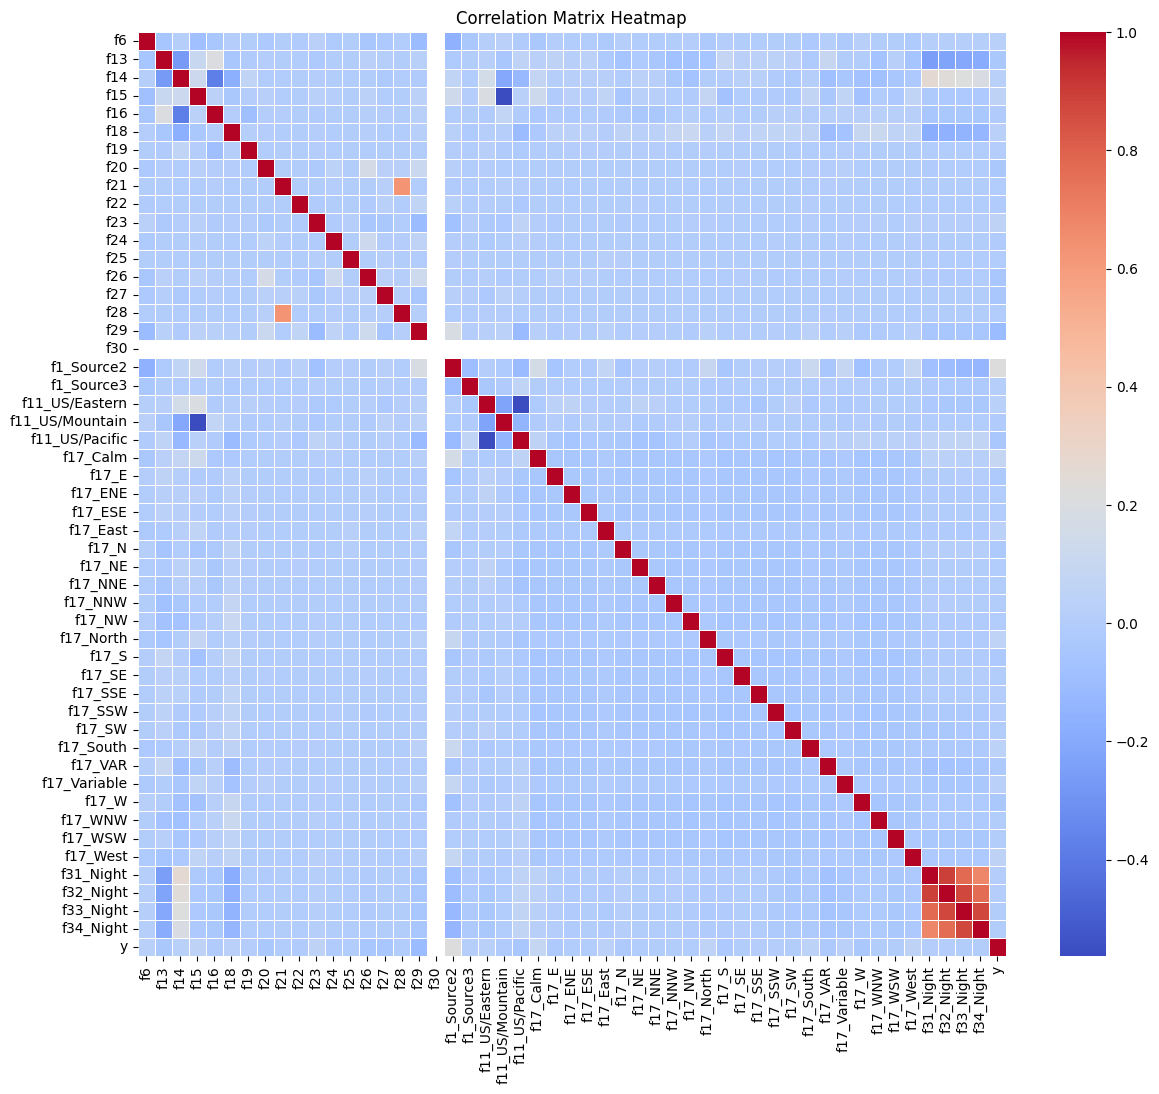

In [169]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,12))
sns.heatmap(
    corr,
    annot=False,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap")
plt.show()

In [170]:
df['f30'].value_counts()

f30
0    100000
Name: count, dtype: int64

The reason for why 'f30' column is all blank is because f30 is constant.

In [171]:
corr_target = corr['y'].abs().sort_values(ascending=False)
corr_target.head(15)

y                 1.000000
f1_Source2        0.219181
f29               0.106442
f17_Calm          0.085623
f17_North         0.057551
f17_West          0.051106
f23               0.050861
f26               0.048103
f11_US/Pacific    0.047944
f15               0.047591
f27               0.045762
f17_South         0.044015
f17_East          0.039641
f13               0.035579
f17_W             0.032761
Name: y, dtype: float64

In [172]:
selected_features = corr_target.index[1:26]
df = df[selected_features.tolist() + ['y']]
df.shape

(100000, 26)

Now, we select the top 25 most important features based on their correlation with the target variable and .